# BigBasket Category Performance Diagnostic — Part 4

This notebook independently cleans `orders_raw.csv`, analyzes revenue with Pandas, and cross-validates the top category and supplier against Part 1's clean SQL diagnostic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("orders_raw shape:", orders.shape)
print("products shape:", products.shape)

orders.info()
display(orders.describe(include="all"))
display(orders["status"].value_counts())

orders_raw shape: (508, 11)
products shape: (31, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000


status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

### Initial data-quality observations

The raw export has more than 500 rows because duplicate order rows were deliberately injected. The `city` and `category` fields contain inconsistent casing/whitespace, `amount_inr` contains missing values, and some revenue values are unusually large. Rating nulls are expected for non-delivered orders and are handled separately below.

In [2]:
before = len(orders)
df = orders.drop_duplicates(subset="order_id", keep="first").copy()
removed = before - len(df)
print("Rows before:", before)
print("Duplicate rows removed:", removed)
print("Rows after:", len(df))

Rows before: 508
Duplicate rows removed: 8
Rows after: 500


### Cleaning city and category

Use `str.strip()` followed by `str.title()` as required. This restores the canonical labels used in Parts 1–3.

In [3]:
df["city"] = df["city"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()

print("Cities:", sorted(df["city"].dropna().unique().tolist()))
print("Categories:", sorted(df["category"].dropna().unique().tolist()))

Cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


In [4]:
df["amount_inr"] = pd.to_numeric(df["amount_inr"], errors="coerce")
missing_amount = df["amount_inr"].isna().sum()
print("Missing amount_inr rows:", missing_amount)

cancelled_pending_rating_nulls = df.loc[df["status"].isin(["Cancelled", "Pending"]), "rating"].isna().sum()
print("Cancelled/Pending rows with null rating:", cancelled_pending_rating_nulls)
print("Rating nulls are left unchanged because ratings are only assigned to Delivered orders.")

Missing amount_inr rows: 10
Cancelled/Pending rows with null rating: 66
Rating nulls are left unchanged because ratings are only assigned to Delivered orders.


### IQR outlier detection and capping

The IQR calculation is performed only on Delivered orders with non-null revenue. Values above the upper fence are capped rather than dropped. Missing revenue rows are excluded from revenue calculations and are not replaced with zero or a mean.

In [5]:
delivered_nonnull = df.loc[(df["status"] == "Delivered") & df["amount_inr"].notna(), "amount_inr"]
q1 = delivered_nonnull.quantile(0.25)
q3 = delivered_nonnull.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
capped_count = (delivered_nonnull > upper_fence).sum()

print(f"Q1 = {q1}")
print(f"Q3 = {q3}")
print(f"IQR = {iqr}")
print(f"Upper fence = {upper_fence}")
print(f"Rows capped = {capped_count}")

df["capped_amount_inr"] = df["amount_inr"]
delivered_mask = (df["status"] == "Delivered") & df["capped_amount_inr"].notna()
df.loc[delivered_mask, "capped_amount_inr"] = df.loc[delivered_mask, "capped_amount_inr"].clip(upper=upper_fence)

Q1 = 90.0
Q3 = 275.0
IQR = 185.0
Upper fence = 552.5
Rows capped = 16


### Derived fields

In [6]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["revenue_per_unit"] = df["capped_amount_inr"] / df["quantity"]
df["is_delivered"] = df["status"].eq("Delivered")

display(df.head())

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,capped_amount_inr,month,month_name,revenue_per_unit,is_delivered
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,175.0,3,March,35.0,True
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,60.0,5,May,60.0,True
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,150.0,6,June,75.0,True
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,30.0,3,March,30.0,True
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,220.0,4,April,110.0,True


### Category revenue and supplier cross-validation

Revenue calculations use Delivered orders only and exclude rows where `amount_inr` is missing. Supplier is brought in by merging the cleaned orders with `products.csv` on `product_id`.

In [7]:
revenue_df = df.loc[df["is_delivered"] & df["capped_amount_inr"].notna()].copy()

category_revenue = (
    revenue_df.groupby("category")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)
display(category_revenue.to_frame("capped_revenue_inr"))

top_category = category_revenue.index[0]
print("Top category by revenue:", top_category)

merged = pd.merge(
    revenue_df,
    products[["product_id", "supplier"]],
    on="product_id",
    how="left"
)
supplier_revenue = (
    merged.groupby("supplier")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)
display(supplier_revenue.to_frame("capped_revenue_inr"))

top_supplier = supplier_revenue.index[0]
print("Top supplier by revenue:", top_supplier)

print("Cross-validation — top category matches Part 1:", top_category == "Household Essentials")
print("Cross-validation — top supplier matches Part 1:", top_supplier == "HomeEssentials Traders")

,capped_revenue_inr
category,
Household Essentials,20910.0
Bakery,14975.0
Personal Care,14594.5
Dairy & Eggs,13675.0
Snacks & Beverages,11312.5
Fruits & Vegetables,9170.0


Top category by revenue: Household Essentials


,capped_revenue_inr
supplier,
HomeEssentials Traders,20910.0
BakeHouse Supplies,18550.0
CarePlus Distributors,14594.5
DairyBest Ltd,10710.0
SnackHub India,7737.5
FreshFarms Co,5490.0
GreenValley Traders,3680.0
CountryEggs Farms,2965.0


Top supplier by revenue: HomeEssentials Traders
Cross-validation — top category matches Part 1: True
Cross-validation — top supplier matches Part 1: True


### Visualization 1: Category revenue

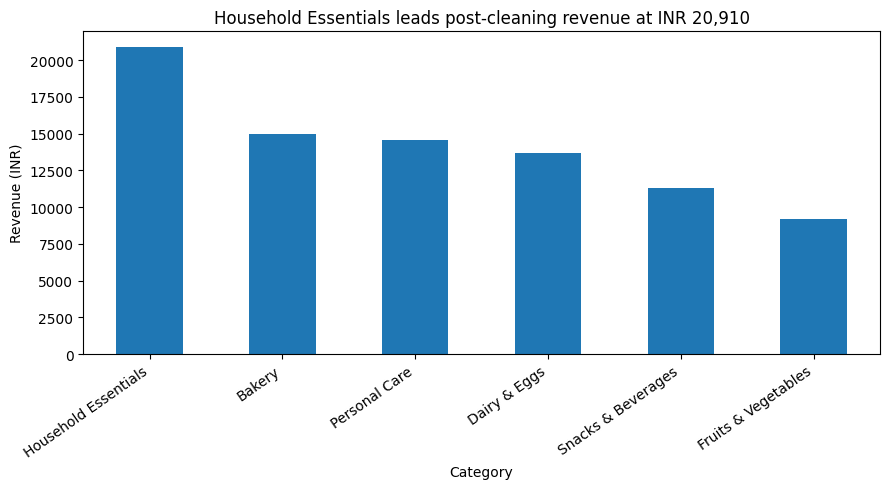

In [8]:
ax = category_revenue.plot(kind="bar", figsize=(9, 5))
ax.set_title("Household Essentials leads post-cleaning revenue at INR 20,910")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Visualization 2: Monthly revenue trend

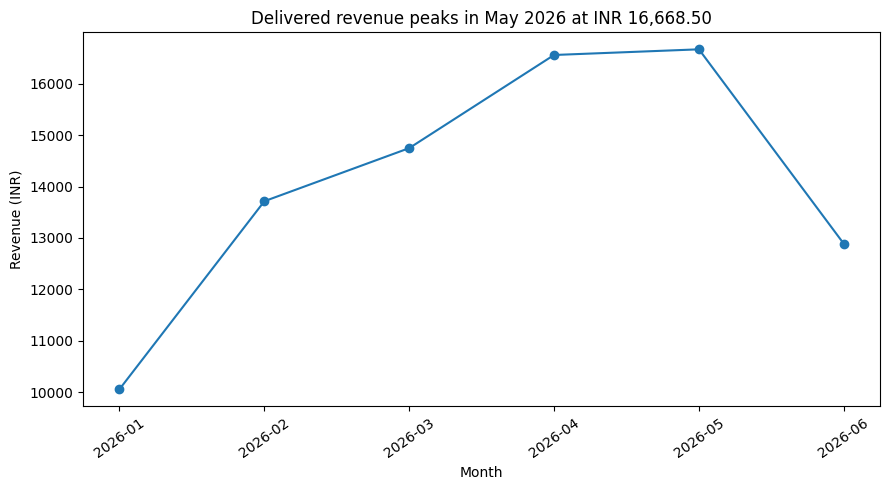

In [9]:
monthly_revenue = (
    revenue_df.groupby(revenue_df["order_date"].dt.to_period("M"))["capped_amount_inr"]
    .sum()
)
monthly_revenue.index = monthly_revenue.index.astype(str)

ax = monthly_revenue.plot(kind="line", marker="o", figsize=(9, 5))
ax.set_title("Delivered revenue peaks in May 2026 at INR 16,668.50")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (INR)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### Visualization 3: Supplier revenue

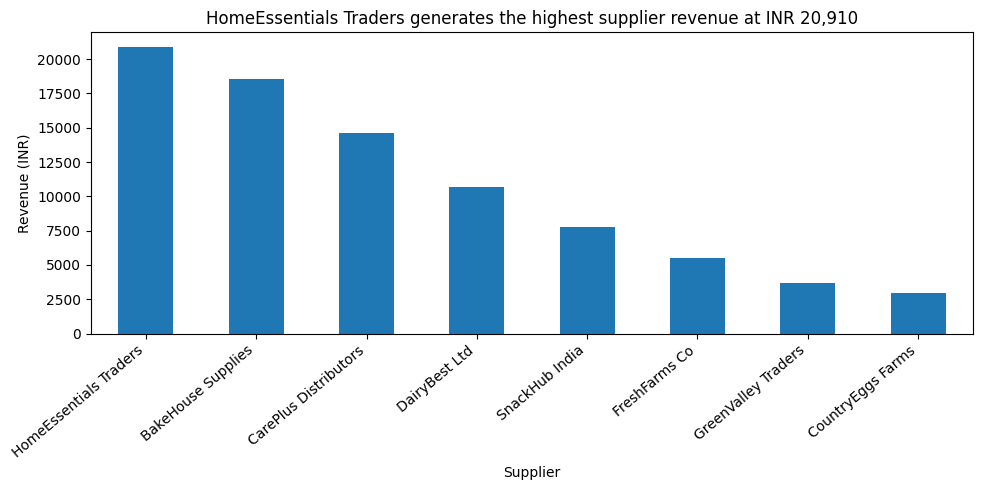

In [10]:
ax = supplier_revenue.head(8).plot(kind="bar", figsize=(10, 5))
ax.set_title("HomeEssentials Traders generates the highest supplier revenue at INR 20,910")
ax.set_xlabel("Supplier")
ax.set_ylabel("Revenue (INR)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

## Exactly 3 observations

**1. What:** Household Essentials is the top category at INR 20,910 after cleaning and capping, while Fruits & Vegetables is lowest at INR 9,170.  
**Why it matters:** The category revenue spread is INR 11,740, showing materially different revenue contribution across categories.  
**Next step:** Compare the monthly and product-level performance inside these two categories before allocating additional catalog or marketing effort.

**2. What:** Monthly delivered revenue rises from INR 10,059.50 in January to a peak of INR 16,668.50 in May, then falls to INR 12,888.00 in June.  
**Why it matters:** Revenue is not evenly distributed across the six-month period, so the May peak is an important reference point for the category team.  
**Next step:** Review which categories and products contributed to the May peak and whether June's decline is concentrated in specific categories.

**3. What:** HomeEssentials Traders is the highest-revenue supplier at INR 20,910, while CountryEggs Farms is lowest at INR 2,965 among suppliers represented in the cleaned delivered-revenue data.  
**Why it matters:** Supplier revenue is concentrated unevenly, which can matter when reviewing category supply performance.  
**Next step:** Review HomeEssentials Traders' product-level contribution and CountryEggs Farms' delivered-order volume before making supplier-level decisions.